In [ ]:
# Get the Studio Ghibli Style Images Dataset... and Unzip it

!wget https://github.com/TachibanaYoshino/AnimeGANv2/releases/download/1.0/Hayao.tar.gz
!tar -xzvf Hayao.tar.gz

In [2]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy             as np
import os
import seaborn           as sns

from collections import Counter
from PIL         import Image


In [3]:
# Set the style for the plots
sns.set(style="darkgrid")

Found 1752 images.
Displaying Sample Image... 279.jpg


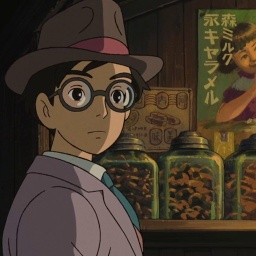

In [4]:
# Path to folder containing images
image_folder = './Hayao/style'

# Collect all image filenames
image_files = []
for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
        image_files.append(filename)
print(f"Found {len(image_files)} images.")


# Display a sample image...
print(f'Displaying Sample Image... {image_files[0]}')
image = Image.open(os.path.join(image_folder, image_files[0]))
display(image)



In [5]:
# Extract RGB values from an image.
def extract_rgb(image_path):
    filepath = os.path.join(image_folder, image_path)
    with Image.open(filepath) as img:
        img = img.convert("RGB")

        pixels = np.array(img) # Get pixel data
        return pixels




# Store the RGB values of all images in the dataset...
all_rgb_values = []
for image_file in image_files:
    pixels = extract_rgb(image_file)
    all_rgb_values.append(pixels)


# Convert the list of arrays into a single array for analysis
all_rgb_values = np.vstack([pixels.reshape(-1, 3) for pixels in all_rgb_values])
print(f"Total RGB values extracted: {all_rgb_values.shape[0]}")


Total RGB values extracted: 114819072


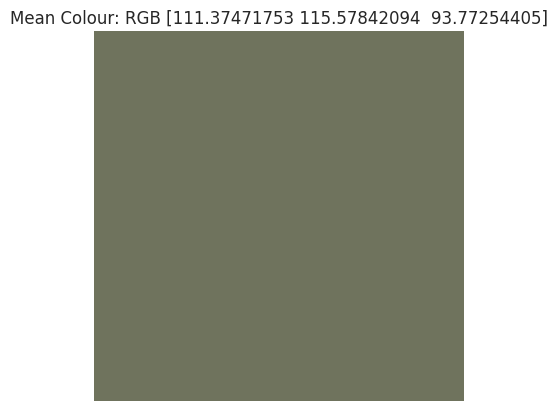

In [6]:
# Calculate mean RGB values across the dataset
mean_rgb = np.mean(all_rgb_values, axis=0)


# Display the mean colour...
mean_image = np.ones((100, 100, 3), dtype=np.uint8) * mean_rgb.astype(np.uint8)
plt.imshow(mean_image)
plt.title(f"Mean Colour: RGB {mean_rgb}")
plt.axis('off')
plt.show()

# This gives us an idea of the average colour across all images, and the overall mood and colour temperature.
# This dataset contains a lot of scenes of nature (hence the green-ish value)

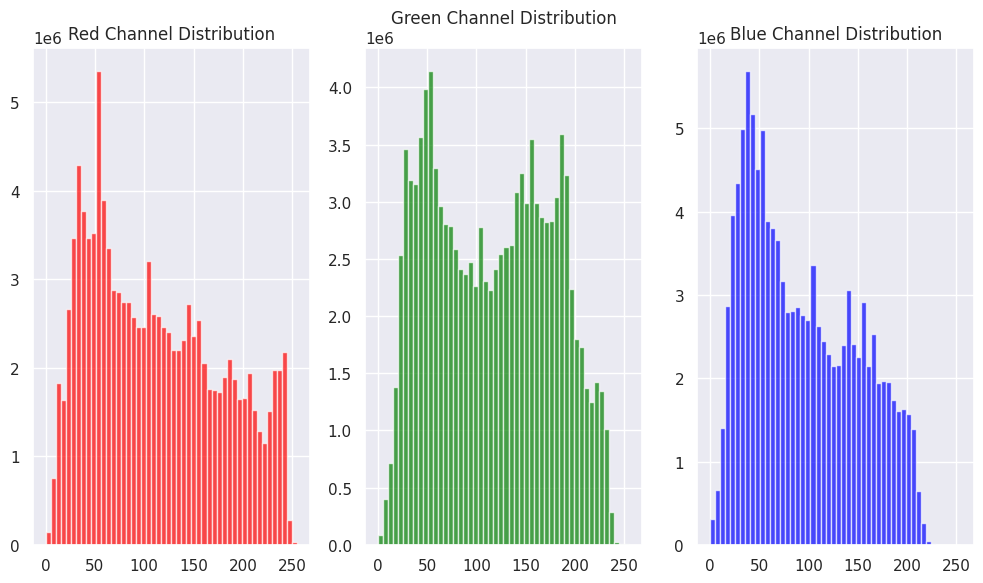

In [7]:
# Separate the RGB values into individual channels to plot their distributions
reds   = all_rgb_values[:, 0]
greens = all_rgb_values[:, 1]
blues  = all_rgb_values[:, 2]


# Plot histograms for each colour channel
plt.figure(figsize=(10, 6))

# Red
plt.subplot(1, 3, 1)
plt.hist(reds, bins=50, color='red', alpha=0.7)
plt.title('Red Channel Distribution')
# Green
plt.subplot(1, 3, 2)
plt.hist(greens, bins=50, color='green', alpha=0.7)
plt.title('Green Channel Distribution')
# Blue
plt.subplot(1, 3, 3)
plt.hist(blues, bins=50, color='blue', alpha=0.7)
plt.title('Blue Channel Distribution')

plt.tight_layout()
plt.show()

# This shows us how frequently each intensity (0–255) appears for each colour channel across all pixels.
# The graphs peak towards the lower values, showing that most of the images use lighter pastel colours.
# Green also seems to be dominating in the images in the dataset.

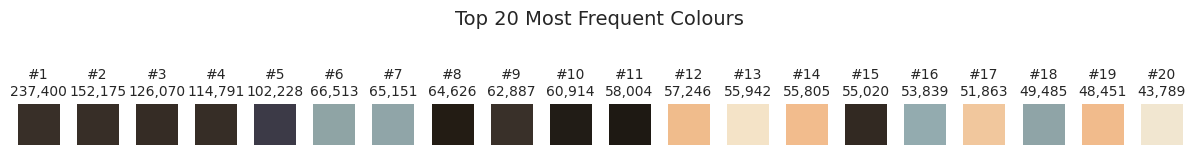

In [9]:
# Plots the top N most common colours from a numpy array of RGB colour values.
def plot_top_colours(rgb_values, top_n=20):

    # Convert values to tuples to be counted
    rgb_tuples = [tuple(colour) for colour in rgb_values.astype(int)]

    # Count occurrences of each colour and get the top N most common colours
    colour_counts = Counter(rgb_tuples)
    top_colours   = colour_counts.most_common(top_n)

    # Plot...
    plt.figure(figsize=(12, 2))

    for idx, (colour, count) in enumerate(top_colours):
        plt.subplot(1, top_n, idx + 1)
        swatch = np.ones((100, 100, 3), dtype=np.uint8) * np.array(colour, dtype=np.uint8)
        plt.imshow(swatch)
        plt.axis('off')
        plt.title(f'#{idx+1}\n{count:,}', fontsize=10)

    plt.suptitle(f"Top {top_n} Most Frequent Colours", fontsize=14)
    plt.tight_layout()
    plt.show()



plot_top_colours(all_rgb_values, top_n=20)

# This shows us which colours are the most common in the dataset.
# The pallette here shows which colours the creators use most - these are usually repeated colours like sky blues, grass greens and skin tones.
